# Tugas Praktikum - DBSCAN Clustering

Buat dataset `make_moons` (1000 sampel, noise=0.05) lalu normalisasi, jalankan DBSCAN dengan `eps=0.2` dan `min_samples=5`, evaluasi kualitasnya, visualisasikan hasilnya, kemudian lakukan eksperimen perubahan `eps` dan `min_samples`.

# Pembuatan Dataset

Untuk mempelajari DBSCAN pada data yang bentuknya tidak bulat, kita buat dataset dua bulan sabit menggunakan fungsi `make_moons` dari Scikit-Learn. Berbeda dengan K-Means (lihat Batas Klaster yang Tidak Selalu Linier pada Praktikum 2), DBSCAN berbasis kepadatan sehingga mampu mengikuti bentuk klaster yang melengkung.

Data lalu dinormalisasi agar kedua fitur berada pada skala yang sama, karena `eps` adalah radius jarak yang berlaku pada semua dimensi.

In [1]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

X, labels_true = make_moons(n_samples=1000, noise=0.05, random_state=0)

X = StandardScaler().fit_transform(X)

Visualisasikan data yang dihasilkan dengan cara ini:

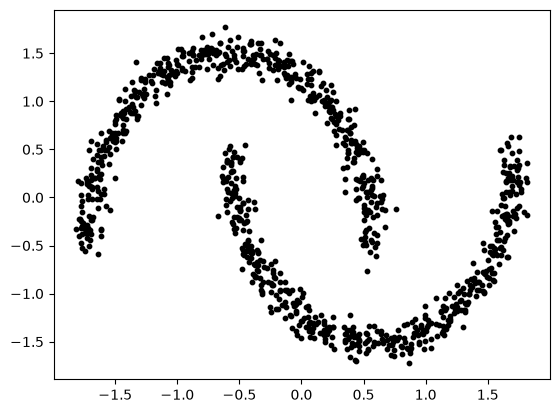

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], s=10, linewidths=1, c="k")
plt.show()

# Compute DBSCAN

Sekarang kita terapkan DBSCAN pada data tersebut.

Label yang ditetapkan oleh DBSCAN dapat diakses melalui atribut `labels_`. Titik data yang dianggap noise akan diberi label khusus.

In [3]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.2, min_samples=5).fit(X)
labels = db.labels_

# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 2
Estimated number of noise points: 0


- `eps=0.2` → jarak maksimum antar titik untuk dianggap tetangga.
- `min_samples=5` → jumlah minimum titik dalam radius eps agar dianggap area padat (core sample).

# Evaluasi Kualitas Klasterisasi

Karena kita menggunakan dataset sintetis (make_moons), kita tahu label aslinya (labels_true). Ini memungkinkan kita mengukur kualitas DBSCAN dengan berbagai metrik evaluasi.

In [4]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print(
    "Adjusted Mutual Information:"
    f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}"
)
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
Adjusted Rand Index: 1.000
Adjusted Mutual Information: 1.000
Silhouette Coefficient: 0.392


Nilai Homogeneity, Completeness, V-measure, ARI, dan AMI yang mencapai 1.000 berarti pembagian klaster DBSCAN persis sama dengan label asli bulan sabit. DBSCAN berhasil memisahkan klaster melengkung yang gagal dipisahkan K-Means.

Silhouette Coefficient hanya 0.392 karena bentuk klaster bulan sabit memanjang, sehingga jarak antar titik di dalam satu klaster bervariasi; metrik ini memang lebih menguntungkan klaster berbentuk bulat.

# Visualisasi Hasil Klasterisasi

Kita akan memvisualisasikan hasil DBSCAN.

Core sample ditampilkan dengan titik besar.

Non-core sample ditampilkan dengan titik kecil.

Noise ditampilkan dengan warna hitam.

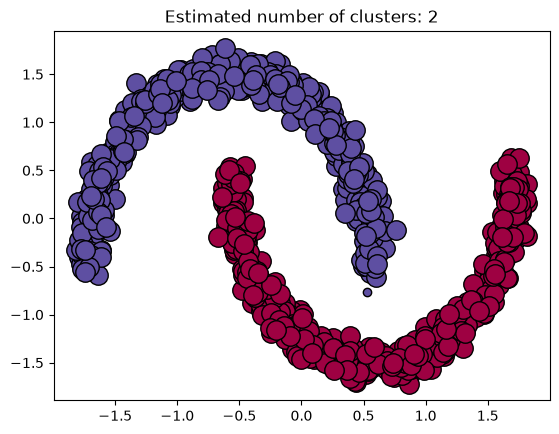

In [5]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

👉 Interpretasi visual:

Titik besar berwarna → core samples dalam klaster.

Titik kecil berwarna → non-core samples, tetap termasuk klaster.

Titik hitam → noise/outlier.

Karena data bulan sabit dengan noise=0.05 sangat rapat, hampir semua titik menjadi core sample sehingga noise nyaris tidak terlihat pada hasil ini.

# Eksperimen Pengaruh eps dan min_samples

Parameter eps dan min_samples diubah-ubah untuk dilihat dampaknya terhadap jumlah klaster, jumlah noise, dan kualitas evaluasi. Fungsi di bawah menjalankan DBSCAN sekaligus menghitung seluruh metrik yang diperlukan.

In [6]:
import pandas as pd

eps_list = [0.05, 0.1, 0.3, 0.5]
min_samples_list = [3, 10, 20]

def run_dbscan(X, labels_true, eps, min_samples):
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    lab = db.labels_

    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = list(lab).count(-1)

    return {
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters,
        "n_noise": n_noise,
        "Homogeneity": metrics.homogeneity_score(labels_true, lab),
        "Completeness": metrics.completeness_score(labels_true, lab),
        "V-measure": metrics.v_measure_score(labels_true, lab),
        "ARI": metrics.adjusted_rand_score(labels_true, lab),
        "AMI": metrics.adjusted_mutual_info_score(labels_true, lab),
        # Silhouette hanya terdefinisi jika minimal ada 2 klaster
        "Silhouette": metrics.silhouette_score(X, lab) if n_clusters >= 2 else np.nan,
    }

In [7]:
# Jalankan seluruh kombinasi eps dan min_samples
results = []

for eps in eps_list:
    for ms in min_samples_list:
        results.append(run_dbscan(X, labels_true, eps, ms))

# Tambahkan konfigurasi tugas (eps=0.2, min_samples=5) sebagai pembanding
results.append(run_dbscan(X, labels_true, 0.2, 5))

df_results = pd.DataFrame(results).round(3)
df_results

,eps,min_samples,n_clusters,n_noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.05,3,67,197,0.804,0.155,0.260,0.033,0.246,0.078
1,0.05,10,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
2,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
3,0.10,3,3,18,0.983,0.708,0.824,0.854,0.823,0.138
4,0.10,10,9,63,0.939,0.358,0.519,0.435,0.517,0.184
5,0.10,20,6,844,0.157,0.153,0.155,0.010,0.152,-0.409
6,0.30,3,2,0,1.000,1.000,1.000,1.000,1.000,0.392
7,0.30,10,2,0,1.000,1.000,1.000,1.000,1.000,0.392
8,0.30,20,2,0,1.000,1.000,1.000,1.000,1.000,0.392
9,0.50,3,1,0,0.000,1.000,0.000,0.000,0.000,NaN


Rekap dalam bentuk heatmap supaya perubahan jumlah klaster, noise, dan kualitas mudah dibaca per kombinasi.

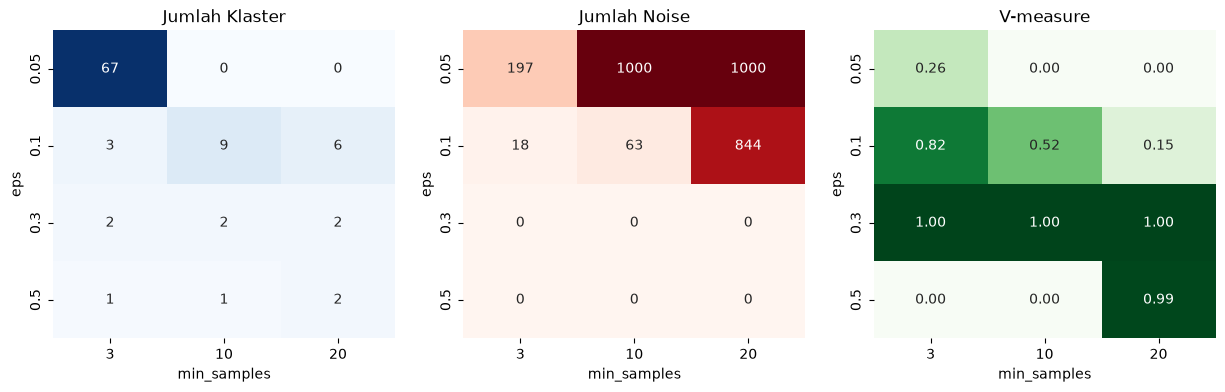

In [8]:
import seaborn as sns

# Hanya kombinasi eksperimen (tanpa baris pembanding eps=0.2)
df_grid = df_results[df_results["eps"] != 0.2]

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

grid = df_grid.pivot(index="eps", columns="min_samples", values="n_clusters")
sns.heatmap(grid, annot=True, fmt="d", cbar=False, ax=ax[0], cmap="Blues")
ax[0].set_title("Jumlah Klaster")

grid = df_grid.pivot(index="eps", columns="min_samples", values="n_noise")
sns.heatmap(grid, annot=True, fmt="d", cbar=False, ax=ax[1], cmap="Reds")
ax[1].set_title("Jumlah Noise")

grid = df_grid.pivot(index="eps", columns="min_samples", values="V-measure")
sns.heatmap(grid, annot=True, fmt=".2f", cbar=False, ax=ax[2], cmap="Greens")
ax[2].set_title("V-measure")
plt.show()

Visualisasikan bentuk klaster yang dihasilkan setiap kombinasi parameter.

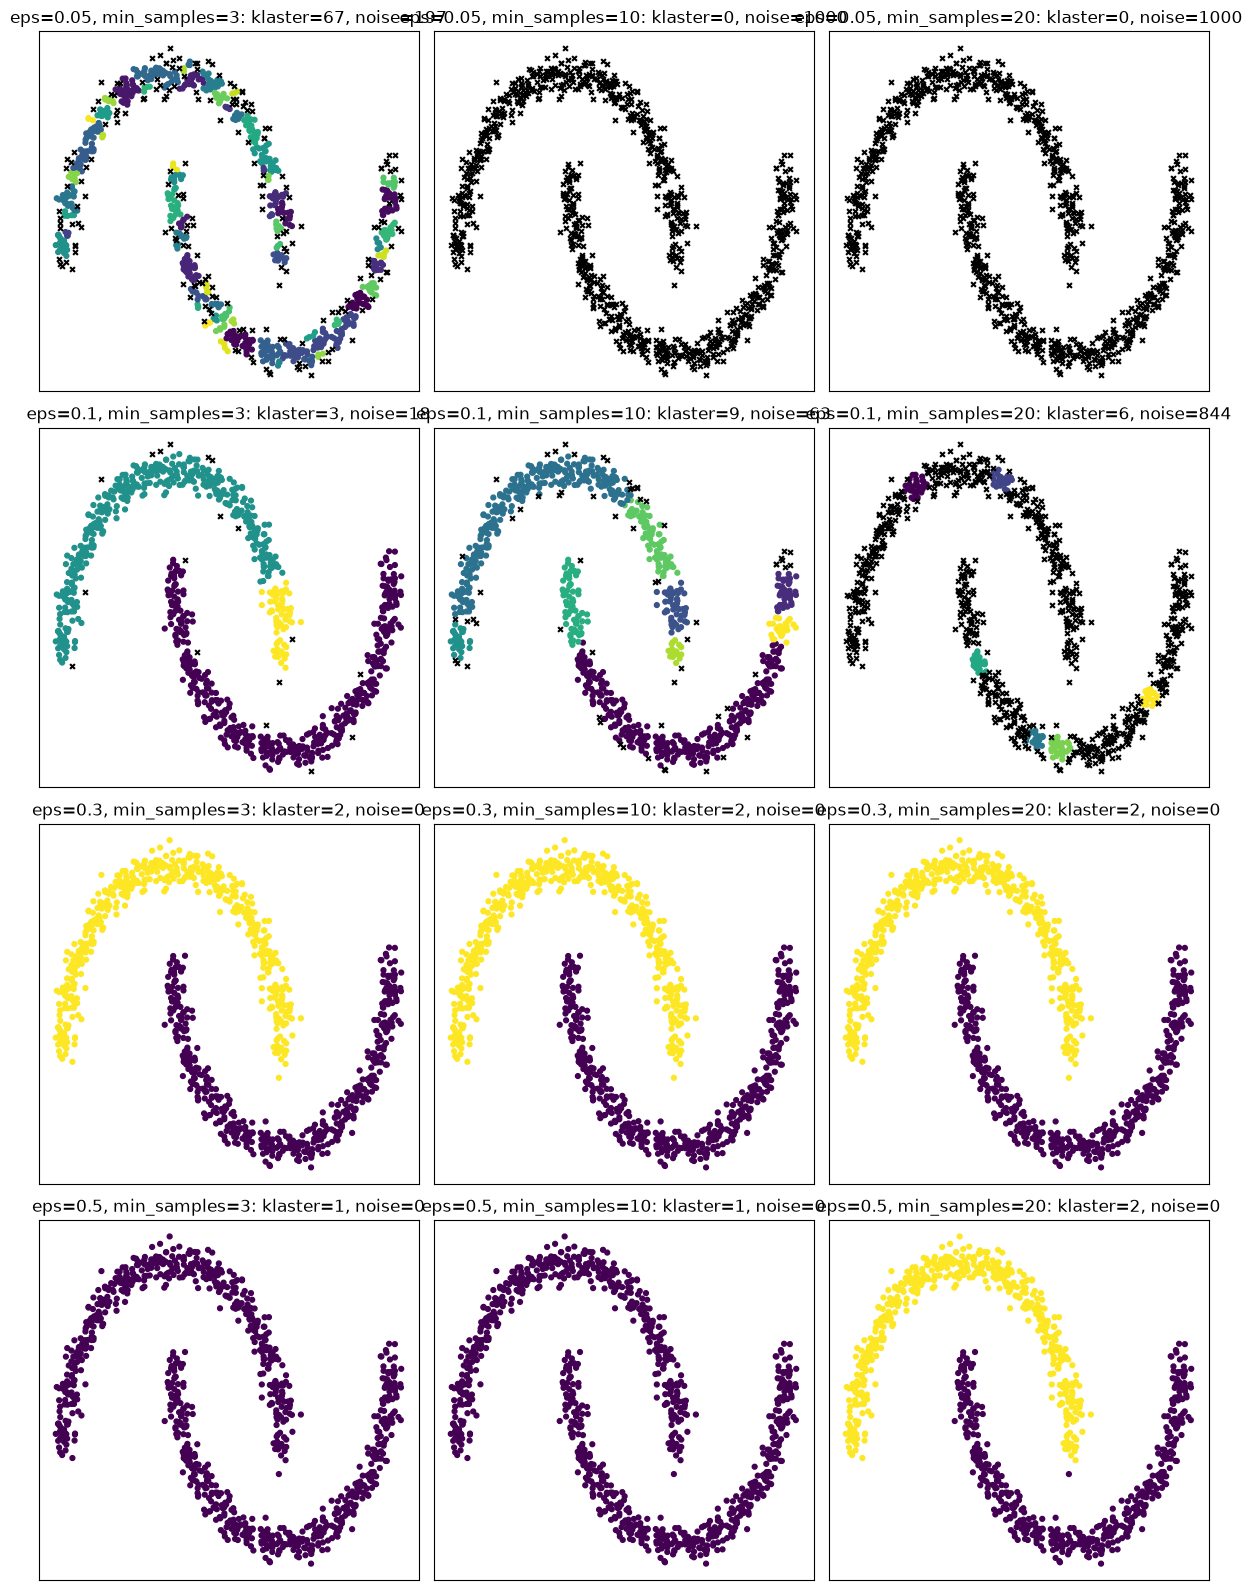

In [9]:
n_rows = len(eps_list)
n_cols = len(min_samples_list)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))

for i, eps in enumerate(eps_list):
    for j, ms in enumerate(min_samples_list):
        db_i = DBSCAN(eps=eps, min_samples=ms).fit(X)
        lab_i = db_i.labels_
        mask_noise = lab_i == -1

        ax = axes[i, j]
        ax.scatter(
            X[~mask_noise, 0], X[~mask_noise, 1],
            c=lab_i[~mask_noise], cmap="viridis", s=12
        )
        ax.scatter(X[mask_noise, 0], X[mask_noise, 1], c="black", s=12, marker="x")

        n_cl = len(set(lab_i)) - (1 if -1 in lab_i else 0)
        ax.set_title(f"eps={eps}, min_samples={ms}: klaster={n_cl}, noise={mask_noise.sum()}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

# Analisis Hasil Eksperimen

In [10]:
# Ambil hasil yang menyimpang dari hasil tugas sebagai bahan pembahasan
df_results[(df_results["n_clusters"] != 2) | (df_results["n_noise"] > 0)]

,eps,min_samples,n_clusters,n_noise,Homogeneity,Completeness,V-measure,ARI,AMI,Silhouette
0,0.05,3,67,197,0.804,0.155,0.260,0.033,0.246,0.078
1,0.05,10,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
2,0.05,20,0,1000,0.000,1.000,0.000,0.000,0.000,NaN
3,0.10,3,3,18,0.983,0.708,0.824,0.854,0.823,0.138
4,0.10,10,9,63,0.939,0.358,0.519,0.435,0.517,0.184
5,0.10,20,6,844,0.157,0.153,0.155,0.010,0.152,-0.409
9,0.50,3,1,0,0.000,1.000,0.000,0.000,0.000,NaN
10,0.50,10,1,0,0.000,1.000,0.000,0.000,0.000,NaN
